# SARIMA
**Modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average)**
El modelo SARIMA es una extensión de ARIMA que permite modelar series de tiempo que no solo tienen una estructura de autocorrelación estándar, sino también un componente estacional (patrones que se repiten en intervalos regulares como meses o trimestres). 

Notación MatemáticaSe define como $SARIMA(p, d, q) \times (P, D, Q)_s$. La ecuación general utilizando el operador de rezago (backshift) $B$ es:

$$\Phi_P(B^s) \phi_p(B) \nabla^d \nabla_s^D Y_t = \Theta_Q(B^s) \theta_q(B) \epsilon_t$$

A. Parte No Estacional $(p, d, q)$

- $\phi_p(B)$ (AutoRegresivo - AR): Representa la relación de la serie con sus propios valores pasados.

$$\phi_p(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p$$

- $\nabla^d$ (Integrado - I): Es el orden de diferenciación simple para hacer la serie estacionaria (eliminar tendencia).

$$\nabla^d = (1-B)^d$$

- $\theta_q(B)$ (Media Móvil - MA): Modela la relación entre la serie y los errores de pronóstico pasados.

$$\theta_q(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q$$

B. Parte Estacional $(P, D, Q)_s$

- $s$: Es el período de estacionalidad (ej. $s=12$ para datos mensuales, $s=4$ para trimestrales).

- $\Phi_P(B^s)$ (SAR): Relación de la serie con valores del mismo periodo en ciclos anteriores.

$$\Phi_P(B^s) = 1 - \Phi_1 B^s - \Phi_2 B^{2s} - \dots - \Phi_P B^{Ps}$$

- $\nabla_s^D$ (SI): Diferenciación estacional. Resta el valor actual menos el valor del ciclo anterior.

$$\nabla_s^D = (1-B^s)^D$$

$\Theta_Q(B^s)$ (SMA): Relación con los errores cometidos en periodos estacionales pasados.

$$\Theta_Q(B^s) = 1 + \Theta_1 B^s + \Theta_2 B^{2s} + \dots + \Theta_Q B^{Qs}$$

---

# SARIMAX

**Modelo SARIMAX (SARIMA con variables Exógenas)** El modelo SARIMAX es una evolución que permite incluir variables externas ($X$) que pueden explicar el comportamiento de la variable objetivo ($Y_t$).

A diferencia de SARIMA, aquí la serie se modela como una regresión lineal donde el residuo ($\eta_t$) sigue un proceso SARIMA:

$$Y_t = \sum_{i=1}^k \beta_i X_{i,t} + \eta_t$$

Donde $\eta_t$ es el error "estructurado" que se descompone así:

$$\Phi_P(B^s) \phi_p(B) \nabla^d \nabla_s^D \eta_t = \Theta_Q(B^s) \theta_q(B) \epsilon_t$$

---

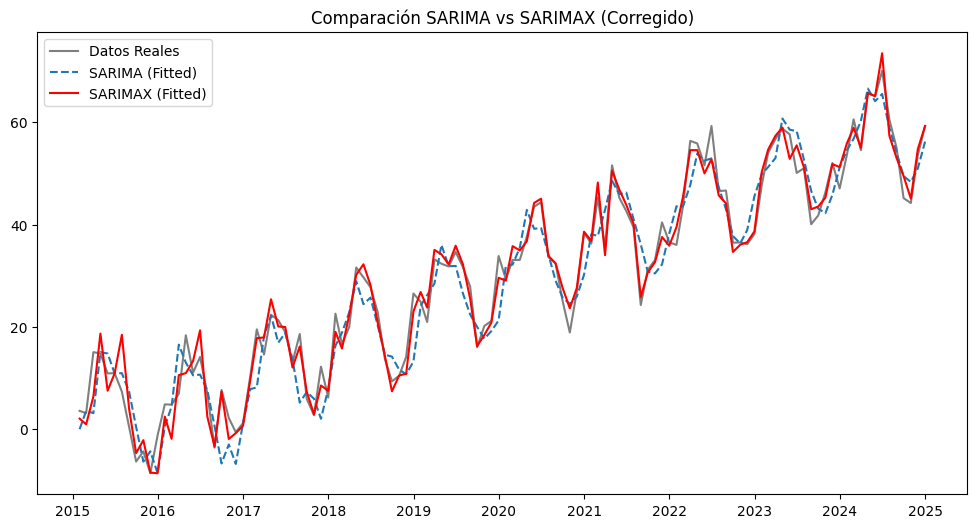

AIC SARIMA: 654.53
AIC SARIMAX: 496.12


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Generación de datos sintéticos
np.random.seed(42)
n = 120  # 10 años de datos mensuales
time = np.arange(n)

# Componentes: Tendencia + Estacionalidad (s=12) + Ruido
trend = 0.5 * time
seasonal = 10 * np.sin(2 * np.pi * time / 12)
exogenous_var = np.random.normal(0, 5, n) # Variable externa
noise = np.random.normal(0, 2, n)

# Variable objetivo Y
y = trend + seasonal + (0.8 * exogenous_var) + noise

# SOLUCIÓN AL ERROR: Cambiar freq='M' por freq='ME'
df = pd.DataFrame({'y': y, 'exog': exogenous_var}, 
                  index=pd.date_range(start='2015-01-01', periods=n, freq='ME'))

# 2. Ajuste del Modelo SARIMA
model_sarima = SARIMAX(df['y'], 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12))
results_sarima = model_sarima.fit(disp=False)

# 3. Ajuste del Modelo SARIMAX
model_sarimax = SARIMAX(df['y'], 
                        exog=df['exog'],
                        order=(1, 1, 1), 
                        seasonal_order=(1, 1, 1, 12))
results_sarimax = model_sarimax.fit(disp=False)

# 4. Visualización
plt.figure(figsize=(12, 6))
plt.plot(df['y'], label='Datos Reales', color='black', alpha=0.5)
plt.plot(results_sarima.fittedvalues, label='SARIMA (Fitted)', linestyle='--')
plt.plot(results_sarimax.fittedvalues, label='SARIMAX (Fitted)', color='red')
plt.legend()
plt.title('Comparación SARIMA vs SARIMAX (Corregido)')
plt.show()

print(f"AIC SARIMA: {results_sarima.aic:.2f}")
print(f"AIC SARIMAX: {results_sarimax.aic:.2f}")